# Tasca S10 – Análisis de datos con Pandas

Este notebook resuelve los ejercicios sobre limpieza, transformación y análisis de datos procedentes de una encuesta a trabajadores, utilizando la biblioteca Pandas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

## NIVEL 1

### 1.1 – Importar, clasificar y verificar el documento de identidad
Importamos el archivo `sprint10.xlsx` como un DataFrame, lo ordenamos por país de origen (y por ciudad en caso de empate), mostramos las primeras 10 filas y comprobamos que no haya duplicados en el número de identificación.

In [2]:
# Importamos el archivo Excel como DataFrame y indicamos que los encabezados estàn en la fila 3
df = pd.read_excel(r'C:\Users\giorg\Desktop\IT Academy\Sprint 10\sprint10.xlsx', header=3)
df

# Ordenamos primero por país de origen y, en caso de empate, por ciudad
df = df.sort_values(by=["País d'origen", 'Ciutat']).reset_index(drop=True)

# Mostramos las primeras 10 filas
display(df.head(10))

# Verificamos que el DNI solo tiene valores únicos (sin duplicados) a través de la propriedad .is_unique
print("¿El DNI tiene solo valores únicos?:", df['DNI'].is_unique)

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
0,21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
1,154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
2,224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
3,278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
4,602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
5,871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
6,281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
7,435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
8,444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
9,487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


¿El DNI tiene solo valores únicos?: True


In [3]:
# EXTRA: Verifico si la columna 'Unnamed: 0' tiene valores únicos:
df["Unnamed: 0"].is_unique

True

In [4]:
# EXTRA: La columna 'Unnamed: 0' tiene valores únicos, así que la renombro en ID para un posible futuro cruze de datos con otra tabla.
df.rename(columns={"Unnamed: 0": "ID"}, inplace=True)

df

,ID,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
0,21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
1,154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
2,224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
3,278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
4,602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,547,Emily,Taylor Jones,89577876S,Regne Unit,Manchester,28,3,1958,D,2.033 €,NaN,1.0,Grup B
996,728,George,Brown Jones,57441590Y,Regne Unit,Manchester,27,12,1979,H,1.130 €,1.0,NaN,Grup A
997,751,Olivia,Brown Brown,58204038A,Regne Unit,Manchester,28,8,1952,A,1.023 €,NaN,1.0,Grup A
998,854,Isla,Jones Brown,28367234K,Regne Unit,Manchester,28,3,1999,D,1.197 €,NaN,1.0,Grup A


### 1.2 – Nuevas columnas y modificaciones en el DataFrame
Creamos la columna «nombre completo», indicamos si la persona ha nacido en España,
utilizamos el NIF como índice, renombramos las columnas de fecha y sustituimos los códigos de género.

In [5]:
# Creamos la columna con el nombre completo (nombre + apellido)
df['Nom Complet'] = df['Nom'] + ' ' + df['Cognoms']

# Creamos columna booleana que indica si la persona nació en España
df['Nascut a Espanya'] = df["País d'origen"] == 'Espanya'

# Ponemos el DNI como índice del DataFrame (nombre de las filas)
df = df.set_index('DNI')

# Renombramos las columnas de fecha de nacimiento para simplificar
df = df.rename(columns={
    'Dia de Naixement': 'Dia',
    'Mes de Naixement': 'Mes',
    'Any de Naixement': 'Any'
})

# Sustituimos los códigos de género por su texto completo
# NC se convierte en NaN porque es un dato faltante
df['Gènere'] = df['Gènere'].replace({
    'H': 'Home',
    'D': 'Dona',
    'A': 'Altres',
    'NC': np.nan
})

# Mostramos todos los cambios en una sola tabla
display(df.head(10))

,ID,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom Complet,Nascut a Espanya
DNI,,,,,,,,,,,,,,,
28973553Z,21,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,False
37399141L,154,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,False
37368317L,224,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,False
21390098Z,278,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.0,NaN,Grup B,Mia Fischer,False
44060014R,602,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.0,NaN,Grup D,Jonas Schneider,False
14773153R,871,Lea,Fischer,Alemanya,Berlín,9,9,1986,Dona,1.370 €,1.0,NaN,Grup A,Lea Fischer,False
23266650S,281,Lea,Müller,Alemanya,Hamburg,14,4,2003,Dona,1.314 €,NaN,1.0,Grup A,Lea Müller,False
83274277X,435,Anna,Müller,Alemanya,Hamburg,1,1,1987,Dona,2.464 €,NaN,1.0,Grup C,Anna Müller,False
60161784X,444,Laura,Schmidt Müller,Alemanya,Hamburg,15,6,1987,NaN,2.035 €,1.0,NaN,Grup C,Laura Schmidt Müller,False


### 1.3 – Combinar las columnas «Fills» y «No Fills»
Utilizamos `.apply()` para fusionar las dos columnas en una sola con los valores «Sí» o «No», trás haber verificado el contenido de las dos columnas.

In [6]:
def tiene_hijos(fila):
    """
    Retorna 'Sí' si la persona té fills, 'No' en cas contrari.
    fila: fila del DataFrame amb les columnes 'Fills' i 'No Fills'
    """
    if pd.notna(fila['Fills']):
        return 'Sí'
    return 'No'

df['Fills'] = df[['Fills', 'No Fills']].apply(tiene_hijos, axis=1)
df = df.drop(columns=['No Fills'])

display(df[['Fills']].head(10))
df



,Fills
DNI,
28973553Z,No
37399141L,Sí
37368317L,No
21390098Z,Sí
44060014R,Sí
14773153R,Sí
23266650S,No
83274277X,No
60161784X,Sí


,ID,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom Complet,Nascut a Espanya
DNI,,,,,,,,,,,,,,
28973553Z,21,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,No,Grup A,Mia Schneider Fischer,False
37399141L,154,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,Sí,Grup B,Laura Schneider Fischer,False
37368317L,224,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,No,Grup B,Lea Schneider Schneider,False
21390098Z,278,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,Sí,Grup B,Mia Fischer,False
44060014R,602,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,Sí,Grup D,Jonas Schneider,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,547,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,No,Grup B,Emily Taylor Jones,False
57441590Y,728,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,Sí,Grup A,George Brown Jones,False
58204038A,751,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,No,Grup A,Olivia Brown Brown,False


### 1.4 – Tabla resumen de salarios por género
Crea una tabla que muestre el salario medio, la mediana, el salario mínimo y el salario máximo para cada género, ordenada por salario medio.

In [7]:
# Limpiamos la columna 'Salari mensual':
df['Salari mensual'] = df['Salari mensual'].str.replace('€', '') # eliminamos el símbolo €
df['Salari mensual'] = df['Salari mensual'].str.replace('.', '') # eliminamos el punto de miles (1.769 → 1769)
df['Salari mensual'] = df['Salari mensual'].str.strip()          # eliminamos espacios en blanco
df['Salari mensual'] = df['Salari mensual'].astype(float)        # convertimos a número decimal


# Agrupamos por género y calculamos estadísticas del salario
tabla_resum = df.groupby('Gènere')['Salari mensual'].agg(
    Sou_Mitja='mean',
    Sou_Media='median',
    Sou_Minim='min',
    Sou_Maxim='max'
).round(2)

# Ordenamos la tabla por sueldo medio de menor a mayor
tabla_resum = tabla_resum.sort_values(by='Sou_Mitja')

display(tabla_resum)

,Sou_Mitja,Sou_Media,Sou_Minim,Sou_Maxim
Gènere,,,,
Dona,1469.44,1361.5,665.0,3021.0
Altres,1626.59,1545.0,703.0,3175.0
Home,1643.25,1531.0,737.0,3356.0


### 1.5 – Tabla dinámica: salario medio por género y país de origen
Crea una tabla dinámica con el género en las filas y el país en las columnas, incluyendo los promedios en los márgenes.
Además, aplica un formato condicional para resaltar los valores más altos.

In [8]:
# Tabla pivot con salario medio por género (filas) y país de origen (columnas)
tabla_pivot = df.pivot_table(
    values='Salari mensual',
    index='Gènere',
    columns="País d'origen",
    aggfunc='mean',
    margins=True,
    margins_name='Mitjana global'
).round(2)

display(tabla_pivot)

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Mitjana global
Gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,NaN,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Mitjana global,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


In [9]:
# (EXTRA) Formato condicional con 2 decimales en la visualización
# Instalamos jinja2, necesario para .style

display(
    tabla_pivot.style
    .format("{:.2f}", na_rep="N/A")   # muestra solo 2 decimales y reemplaza nan
    .background_gradient(cmap='YlOrRd', axis=None)
)

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Mitjana global
Gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,N/A,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Mitjana global,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


### 1.6 – Fecha de nacimiento en formato de fecha y hora y cálculo de la edad
Combinamos las columnas «Día», «Mes» y «Año» en un campo de fecha y hora, y definimos una función para calcular la edad actual.

In [10]:
# Combinamos las columnas Dia, Mes y Any en un campo de fecha datetime utilizandos las palabras reservadas en Pandas para las fechas (year, month, day)
df['Data de Naixement'] = pd.to_datetime(
    df[['Any', 'Mes', 'Dia']].rename(columns={'Any': 'year', 'Mes': 'month', 'Dia': 'day'}) 
).dt.date #eliminamos la hora del datatime para que se necesitamos exportarlo el dato sea solo en formato data

# Función que calcula la edad actual a partir de una fecha de nacimiento
def calcular_edat(data_naixement):
    """
    Calcula la edad actual a partir de una fecha de nacimiento.
    data_naixement: datetime
    """
    avui = date.today()
    edat = avui.year - data_naixement.year
    # Si todavía no ha llegado el cumpleaños este año, restamos 1
    if (avui.month, avui.day) < (data_naixement.month, data_naixement.day):
        edat -= 1
    return edat

# Creamos la columna de edad aplicando la función a cada fila
df['Edat'] = df['Data de Naixement'].apply(calcular_edat)

display(df[['Data de Naixement', 'Edat']].head(10))



,Data de Naixement,Edat
DNI,,
28973553Z,1976-10-22,49
37399141L,1958-02-02,68
37368317L,2005-10-23,20
21390098Z,1950-08-11,75
44060014R,1985-11-22,40
14773153R,1986-09-09,39
23266650S,2003-04-14,23
83274277X,1987-01-01,39
60161784X,1987-06-15,38


## NIVEL 2

### 2.1 – Aumento salarial por grupo profesional
Añadimos el DataFrame de aumentos al principal y actualizamos el salario según el porcentaje correspondiente.

In [11]:
# DataFrame con los porcentajes de incremento por grupo profesional
df_increment = pd.DataFrame({
    "Grup": ["Grup A", "Grup B", "Grup C", "Grup D"],
    "Increment": ["5%", "3,5%", "2%", "8%"]
})

# Quitamos el símbolo % y convertimos a número decimal
df_increment['Increment'] = df_increment['Increment'].str.replace('%', '', regex=False)
df_increment['Increment'] = df_increment['Increment'].str.replace(',', '.', regex=False)
df_increment['Increment'] = df_increment['Increment'].astype(float) / 100

# Eliminamos la columna Increment si ya existe (por si ejecutamos la celda más de una vez)
if 'Increment' in df.columns:
    df = df.drop(columns=['Increment'])

# Unimos el incremento al DataFrame principal por el grupo profesional
df = df.merge(df_increment, left_on='Grup Professional', right_on='Grup', how='left')
df = df.drop(columns=['Grup'])

# Actualizamos el salario con el incremento correspondiente y redondeamos a 2 decimales
df['Salari mensual'] = (df['Salari mensual'] * (1 + df['Increment'])).round(2)

display(df[['Grup Professional', 'Increment', 'Salari mensual']].head(10))


,Grup Professional,Increment,Salari mensual
0,Grup A,0.050,998.55
1,Grup B,0.035,1830.92
2,Grup B,0.035,2083.46
3,Grup B,0.035,1611.50
4,Grup D,0.080,2974.32
5,Grup A,0.050,1438.50
6,Grup A,0.050,1379.70
7,Grup C,0.020,2513.28
8,Grup C,0.020,2075.70
9,Grup B,0.035,2113.47


### 2.2 – Exportación de datos por grupo profesional. 
Exportamos un archivo para cada grupo y un archivo resumen con el número de trabajadores, el salario medio y la edad media.

In [12]:
# Exportamos un archivo Excel por cada grupo profesional usando un bucle
for grup in df['Grup Professional'].unique():
    df_grup = df[df['Grup Professional'] == grup]
    nom_fitxer = f"dades_{grup.replace(' ', '')}.xlsx"
    df_grup.to_excel(nom_fitxer, index=True)
    print(f"Exportado: {nom_fitxer}")

# DataFrame resumen: número de trabajadores, sueldo medio y edad mediana por grupo
df_resum = df.groupby('Grup Professional').agg(
    Treballadors=('Salari mensual', 'count'),
    Sou_Mig=('Salari mensual', 'mean'),
    Edat_Mediana=('Edat', 'median')
).round()

# Exportamos también el resumen
df_resum.to_excel('resum_grups.xlsx')
display(df_resum)

Exportado: dades_GrupA.xlsx
Exportado: dades_GrupB.xlsx
Exportado: dades_GrupD.xlsx
Exportado: dades_GrupC.xlsx


,Treballadors,Sou_Mig,Edat_Mediana
Grup Professional,,,
Grup A,490,1213.0,51.0
Grup B,318,1725.0,48.0
Grup C,137,2289.0,52.0
Grup D,55,3101.0,44.0


## NIVEL 3

### 3.1 –  Función de generación automática de gráficos
Definimos una función que detecta el tipo de cada columna y crea automáticamente el gráfico más adecuado.
La probamos con el conjunto de datos `penguins` de seaborn.

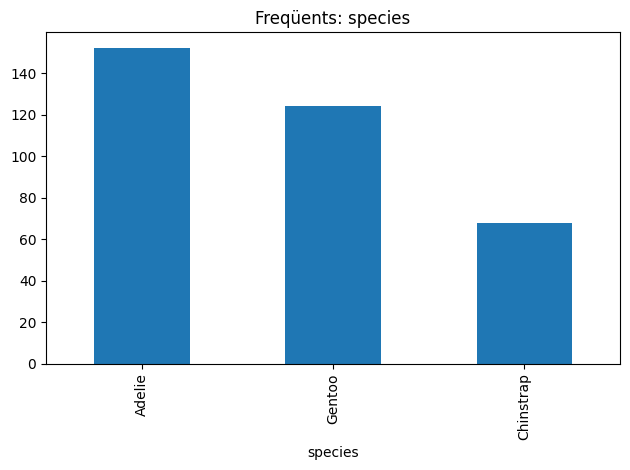

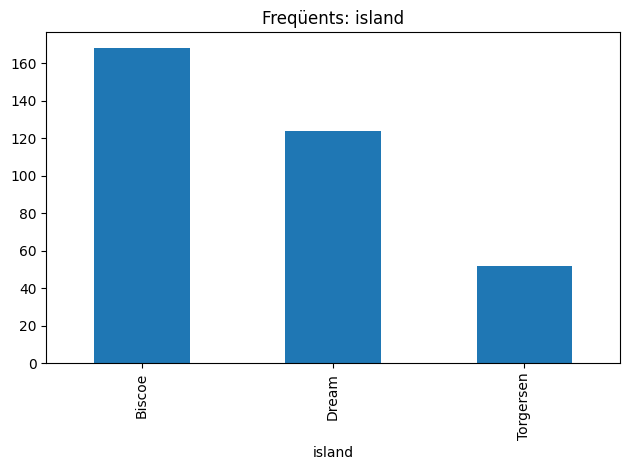

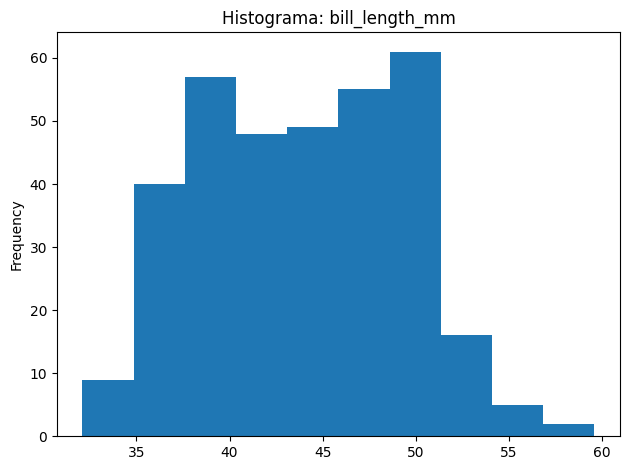

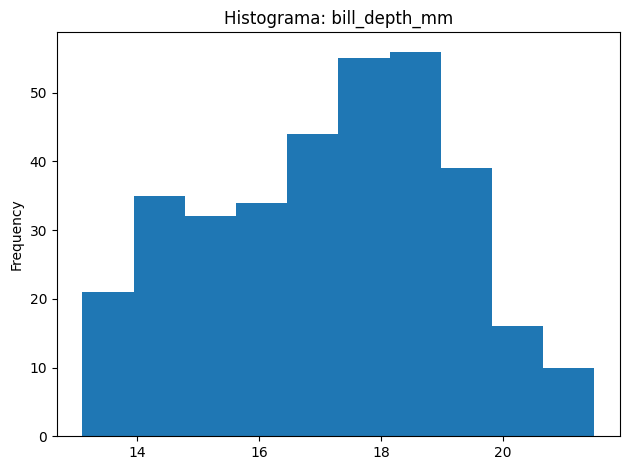

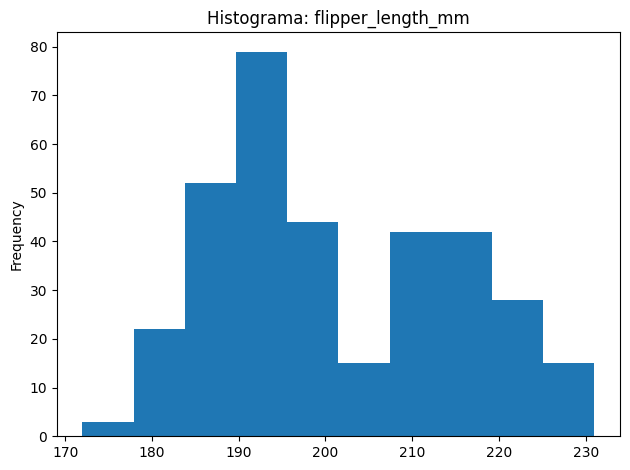

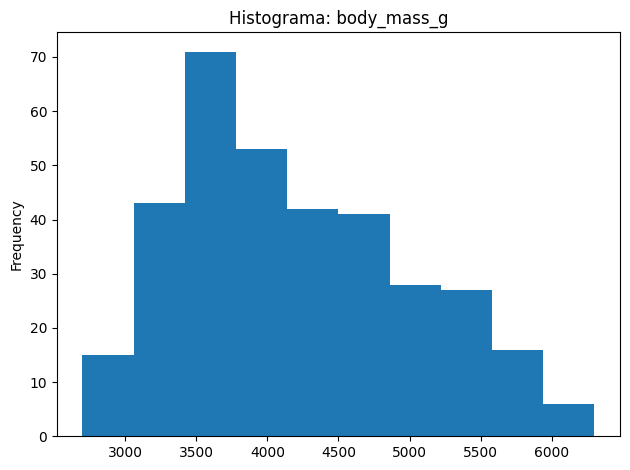

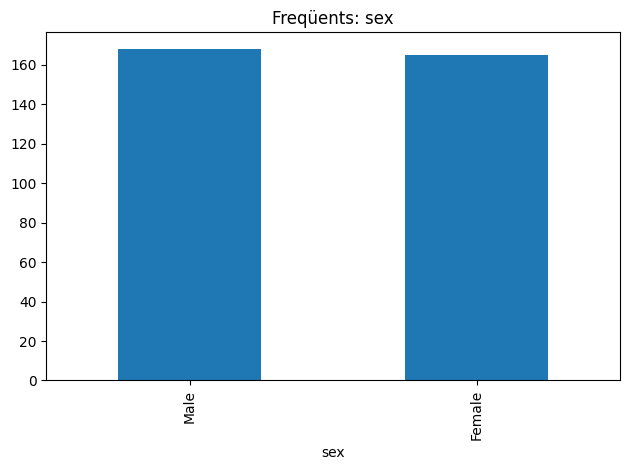

In [13]:
def generar_grafics(dataframe):
    """
    Genera un gráfico automático para cada columna de un DataFrame.
    - Numérica (float64, int64): histograma
    - Fecha (datetime64): barras por año
    - Categórica (object): barras de los 10 valores más frecuentes
    dataframe: DataFrame de pandas
    """
    for columna in dataframe.columns:
        tipo = dataframe[columna].dtype

        if tipo in ['float64', 'int64']:
            # Variable numérica → histograma
            dataframe[columna].plot(kind='hist', title=f'Histograma: {columna}')

        elif tipo == 'datetime64[ns]':
            # Variable de fecha → frecuencia de años
            dataframe[columna].dt.year.value_counts().sort_index().plot(kind='bar', title=f'Anys: {columna}')

        else:
            # Variable categórica → los 10 valores más frecuentes
            dataframe[columna].value_counts().head(10).plot(kind='bar', title=f'Freqüents: {columna}')

        plt.tight_layout()
        plt.savefig(f'grafic_{columna}.png')
        plt.show()

df_pinguins = sns.load_dataset('penguins')
generar_grafics(df_pinguins)

### 3.2 – Matriz de distancias y propuesta de ruta
Cargamos la matriz de distancias entre las ciudades españolas, eliminamos las islas y aplicamos el algoritmo del vecino más cercano para calcular una ruta corta que recorra todas las ciudades.

In [14]:
# Cargamos la matriz de distancias con ciudades como índice y columnas
df_dist = pd.read_excel('matriu_distancies.xlsx', index_col=0)

# Eliminamos las ciudades insulares porque no se puede ir en coche
df_dist = df_dist.drop(
    index=['Las Palmas de Gran Canaria', 'Palma'],
    columns=['Las Palmas de Gran Canaria', 'Palma']
)

print(f"Ciudades disponibles ({len(df_dist.columns)}):")
print(list(df_dist.columns))

Ciudades disponibles (13):
['Barcelona', 'Valencia', 'Sevilla', 'Zaragoza', 'Málaga', 'Murcia', 'Bilbao', 'Alicante', 'Córdoba', 'Valladolid', 'Vigo', 'Gijón', 'Hospitalet de Llobregat']


In [2]:
# Algoritmo del vecino más cercano: siempre vamos a la ciudad no visitada más próxima
def ruta_mes_curta(matriu, ciutat_origen):
    ''' 
    Propone la ruta más corta para visitar todas las ciudades utilizando el algoritmo del vecino más cercano.
    matrix: DataFrame con las distancias entre ciudades
    origin_city: str - la ciudad desde la que comienza la ruta
    '''
    ciutats = list(matriu.columns)
    visitades = [ciutat_origen]
    distancia_total = 0
    ciutat_actual = ciutat_origen

    while len(visitades) < len(ciutats):
        # Obtenemos solo las ciudades que aún no hemos visitado
        pendents = [c for c in ciutats if c not in visitades]
        distancies = matriu.loc[ciutat_actual, pendents]
        # Seleccionamos la ciudad más cercana
        seguent = distancies.idxmin()
        distancia_total += distancies.min()
        visitades.append(seguent)
        ciutat_actual = seguent

    return visitades, distancia_total

In [16]:
# Calculamos la ruta empezando desde Barcelona, para comprobar los resultados anterior
ruta, distancia = ruta_mes_curta(df_dist,'Barcelona')

print("Ruta proposada des de Barcelona:")
print(" → ".join(ruta))
print(f"\nDistància total: {distancia:.0f} km")

# (EXTRA) ¿Desde qué ciudad la ruta total es más corta?
resultats = {}
for ciutat in df_dist.columns:
    _, dist = ruta_mes_curta(df_dist, ciutat)
    resultats[ciutat] = dist

millor_ciutat = min(resultats, key=resultats.get)
print(f"\n[EXTRA] La ciutat d'origen amb la ruta més curta és: {millor_ciutat}")
print(f"Distància total mínima: {resultats[millor_ciutat]:.0f} km")

Ruta proposada des de Barcelona:
Barcelona → Hospitalet de Llobregat → Zaragoza → Valencia → Alicante → Murcia → Córdoba → Sevilla → Málaga → Valladolid → Gijón → Bilbao → Vigo

Distància total: 2778 km

[EXTRA] La ciutat d'origen amb la ruta més curta és: Barcelona
Distància total mínima: 2778 km
